## Problem 2: Superimposed Sine Waves

**Goal**: Recover the unknown heat source $f(x,t)$.

**Given Solution ($u_{true}$)**:
$$u(x,t) = [\sin(\pi x) - 0.5\sin(2\pi x)] \sin(\pi t)$$

**Derived Source ($f_{true}$)**:
$$f = u_t - u_{xx}$$
$$f = \pi \cos(\pi t) [\sin(\pi x) - 0.5\sin(2\pi x)] + \pi^2 \sin(\pi t) [\sin(\pi x) - 2\sin(2\pi x)]$$

**Boundary Conditions**: 
$u(0,t) = 0, u(1,t) = 0$ (Dirichlet zero boundaries).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Parameters and Grid Setup (Problem 2) ---
nx = 200      # number of intervals (or points – just be consistent)
nt = 50
alpha = 1.0 
L=1.0
x0, x1 = 0.0, 1.0
T = 0.5  

dx = (x1 - x0) / nx
dt = T / nt
x = np.linspace(x0, x1, nx)   # including boundaries
t = np.linspace(0.0, T,  nt)
X, T_mesh = np.meshgrid(x, t)

# Stability check
cfl_number = alpha * dt / (dx**2)
print(f"CFL Number: {cfl_number:.4f}")

CFL Number: 400.0000


## Ground Truth Data Generation (Method of Manufactured Solutions)

We use **Problem 1** to generate the synthetic "observed" data.

* **True Temperature ($u_{true}$)**: $u(x,t) = \sin(2\pi x) + \sin(\pi t)$
* **True Source ($f_{true}$)**: Derived analytically from the heat equation.

In [2]:

# --- 2. Ground Truth Generation (highly oscillatory) ---
omega = 15
# u(x,t) = sin(omega*pi*x) * cos(omega*pi*t)
u_true = np.sin(omega * np.pi * X) * np.cos(omega * np.pi * T_mesh)

# derivatives for u_t - alpha * u_xx = f
u_t  = -omega * np.pi * np.sin(omega * np.pi * X) * np.sin(omega * np.pi * T_mesh)
u_xx = -(omega * np.pi)**2 * np.sin(omega * np.pi * X) * np.cos(omega * np.pi * T_mesh)

f_true = u_t - alpha * u_xx

# perfect observations
u_obs = u_true.copy()

## Solvers (Forward & Adjoint)

We implement two solvers using the Finite Difference Method:

1.  **Forward Solver**: Solves $u_t - u_{xx} = f$ forward in time to get $u$.
2.  **Adjoint Solver**: Solves $-p_t - p_{xx} = (u - u_{obs})$ backward in time to get the adjoint variable $p$.

The gradient of the cost function with respect to $f$ is simply the adjoint variable $p$.

In [4]:
def solve_forward(f_input):
    """
    Backward Euler: u_t - alpha u_xx = f
    """
    u = np.zeros((nt, nx))

    # Initial condition and BCs from ground truth
    u[0, :]  = u_true[0, :]
    u[:, 0]  = u_true[:, 0]      # x = 0
    u[:, -1] = u_true[:, -1]     # x = L

    N_int = nx - 2
    lam = alpha * dt / dx**2

    main = (1.0 + 2.0 * lam) * np.ones(N_int)
    off  = -lam * np.ones(N_int - 1)
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    for n in range(nt - 1):
        u[n+1, 0]  = u_true[n+1, 0]
        u[n+1, -1] = u_true[n+1, -1]

        rhs = u[n, 1:-1].copy() + dt * f_input[n+1, 1:-1]
        rhs[0]  += lam * u[n+1, 0]
        rhs[-1] += lam * u[n+1, -1]

        u[n+1, 1:-1] = np.linalg.solve(A, rhs)

    return u


def solve_adjoint(u_current, u_target):
    """
    -p_t - alpha p_xx = (u - u_target)
    backward in time, backward-Euler-type.
    """
    p = np.zeros((nt, nx))

    N_int = nx - 2
    lam = alpha * dt / dx**2

    main = (1.0 + 2.0 * lam) * np.ones(N_int)
    off  = -lam * np.ones(N_int - 1)
    A = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    for n in range(nt - 2, -1, -1):
        p[n, 0]  = 0.0
        p[n, -1] = 0.0

        residual = u_current[n+1, 1:-1] - u_target[n+1, 1:-1]
        rhs = p[n+1, 1:-1] - dt * residual

        p[n, 1:-1] = np.linalg.solve(A, rhs)

    return p


## Optimization Loop

We iterate to minimize the objective function.

**Configuration**:
* **Learning Rate**: Step size for gradient descent.
* **Non-negativity Constraint**: If `True`, we enforce $f \ge 0$ at every step (Projected Gradient Descent).
    * *Note*: For Problem 1, the true $f$ contains negative values. Enabling this constraint will prevent convergence to the exact true solution, but is often required in real-world physical problems (e.g., heating only).

In [5]:
# --- 4. Optimization Loop ---

LEARNING_RATE = 5     
EPOCHS = 5000
ENABLE_NON_NEGATIVITY = False
LAMBDA_REG = 0.0

f_guess = np.zeros_like(f_true)
loss_history = []

print(f"Starting optimization with Non-negativity Constraint: {ENABLE_NON_NEGATIVITY}")

for epoch in range(EPOCHS + 1):
    u_pred = solve_forward(f_guess)

    misfit = u_pred - u_obs
    data_term = 0.5 * np.sum(misfit**2) * dx * dt
    reg_term  = 0.5 * LAMBDA_REG * np.sum(f_guess**2) * dx * dt
    loss = data_term + reg_term
    loss_history.append(loss)

    p = solve_adjoint(u_pred, u_obs)

    # gradient = LAMBDA_REG * f - p   <-- sign fixed
    gradient = LAMBDA_REG * f_guess - p

    f_guess[1:-1, 1:-1] -= LEARNING_RATE * gradient[1:-1, 1:-1]

    if ENABLE_NON_NEGATIVITY:
        f_guess = np.maximum(f_guess, 0.0)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.6e}")


Starting optimization with Non-negativity Constraint: False
Epoch 0: Loss = 5.951021e-02
Epoch 500: Loss = 5.945891e-02
Epoch 1000: Loss = 5.940765e-02
Epoch 1500: Loss = 5.935644e-02
Epoch 2000: Loss = 5.930528e-02
Epoch 2500: Loss = 5.925415e-02
Epoch 3000: Loss = 5.920308e-02
Epoch 3500: Loss = 5.915204e-02
Epoch 4000: Loss = 5.910105e-02
Epoch 4500: Loss = 5.905011e-02
Epoch 5000: Loss = 5.899921e-02


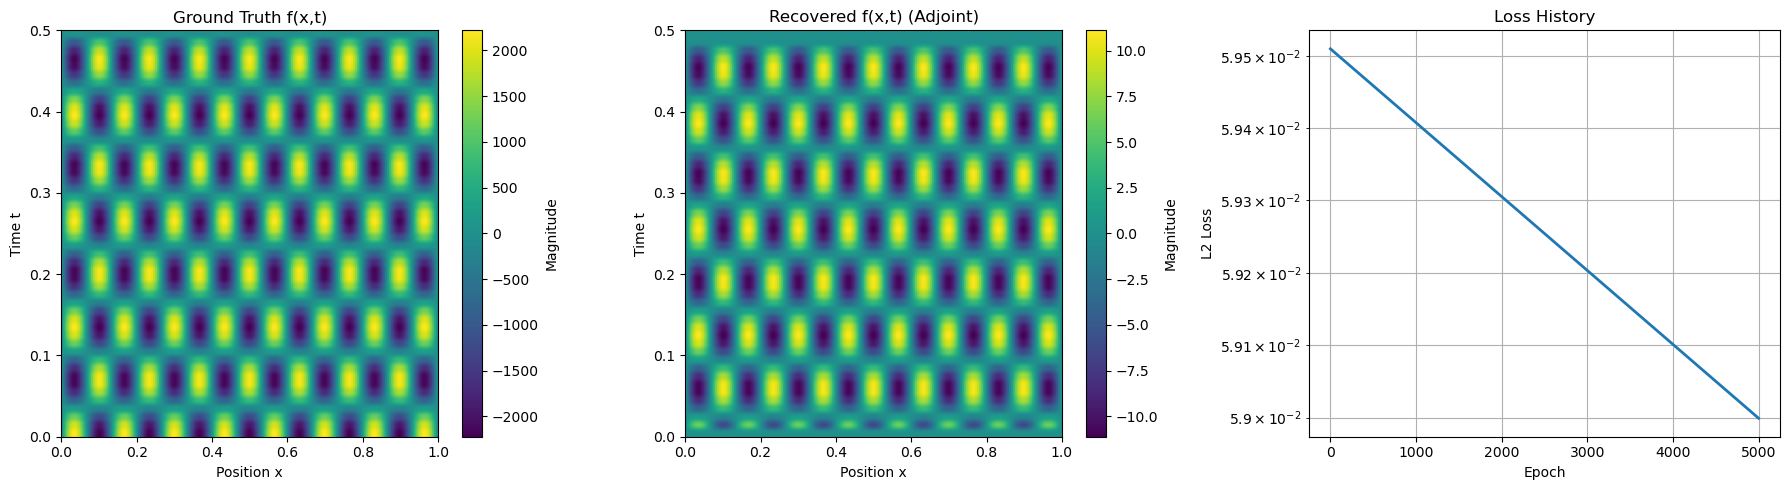

In [6]:
# # --- 5A. Visualization ---

# plt.figure(figsize=(18, 5))

# # Plot 1: True Source Term
# plt.subplot(1, 3, 1)
# plt.title("Ground Truth f(x,t)")
# plt.imshow(f_true, aspect='auto', extent=[0, L, 0, T], origin='lower', cmap='viridis')
# plt.colorbar(label='Magnitude')
# plt.xlabel('Position x')
# plt.ylabel('Time t')

# # Plot 2: Recovered Source Term
# plt.subplot(1, 3, 2)
# title_str = "Recovered f(x,t) (Adjoint)"
# if ENABLE_NON_NEGATIVITY:
#     title_str += "\n(w/ Non-negativity Constraint)"
# plt.title(title_str)
# plt.imshow(f_guess, aspect='auto', extent=[0, L, 0, T], origin='lower', cmap='viridis')
# plt.colorbar(label='Magnitude')
# plt.xlabel('Position x')
# plt.ylabel('Time t')

# # Plot 3: Loss Convergence
# plt.subplot(1, 3, 3)
# plt.title("Loss History")
# plt.plot(loss_history, linewidth=2)
# plt.xlabel('Epoch')
# plt.ylabel('L2 Loss')
# plt.yscale('log')
# plt.grid(True, which="both", ls="-")

# plt.tight_layout()
# plt.show()

plt.figure(figsize=(18, 5))

# Plot 1: True Source Term
plt.subplot(1, 3, 1)
plt.title("Ground Truth f(x,t)")
plt.imshow(
    f_true,
    aspect='auto',
    extent=[0, L, 0, T],
    origin='lower',
    cmap='viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel('Position x')
plt.ylabel('Time t')

# Plot 2: Recovered Source Term
plt.subplot(1, 3, 2)
title_str = "Recovered f(x,t) (Adjoint)"
if ENABLE_NON_NEGATIVITY:
    title_str += "\n(w/ Non-negativity Constraint)"
plt.title(title_str)
plt.imshow(
    f_guess,
    aspect='auto',
    extent=[0, L, 0, T],
    origin='lower',
    cmap='viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel('Position x')
plt.ylabel('Time t')

# Plot 3: Loss Convergence
plt.subplot(1, 3, 3)
plt.title("Loss History")
plt.plot(loss_history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('L2 Loss')
plt.yscale('log')
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()


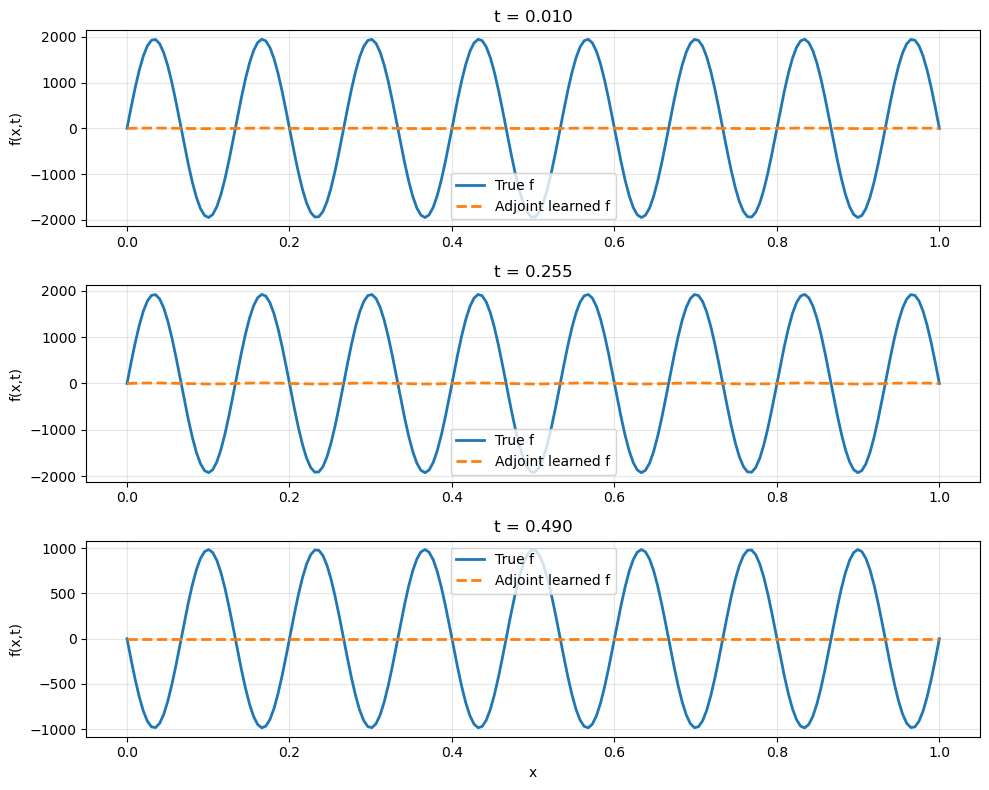

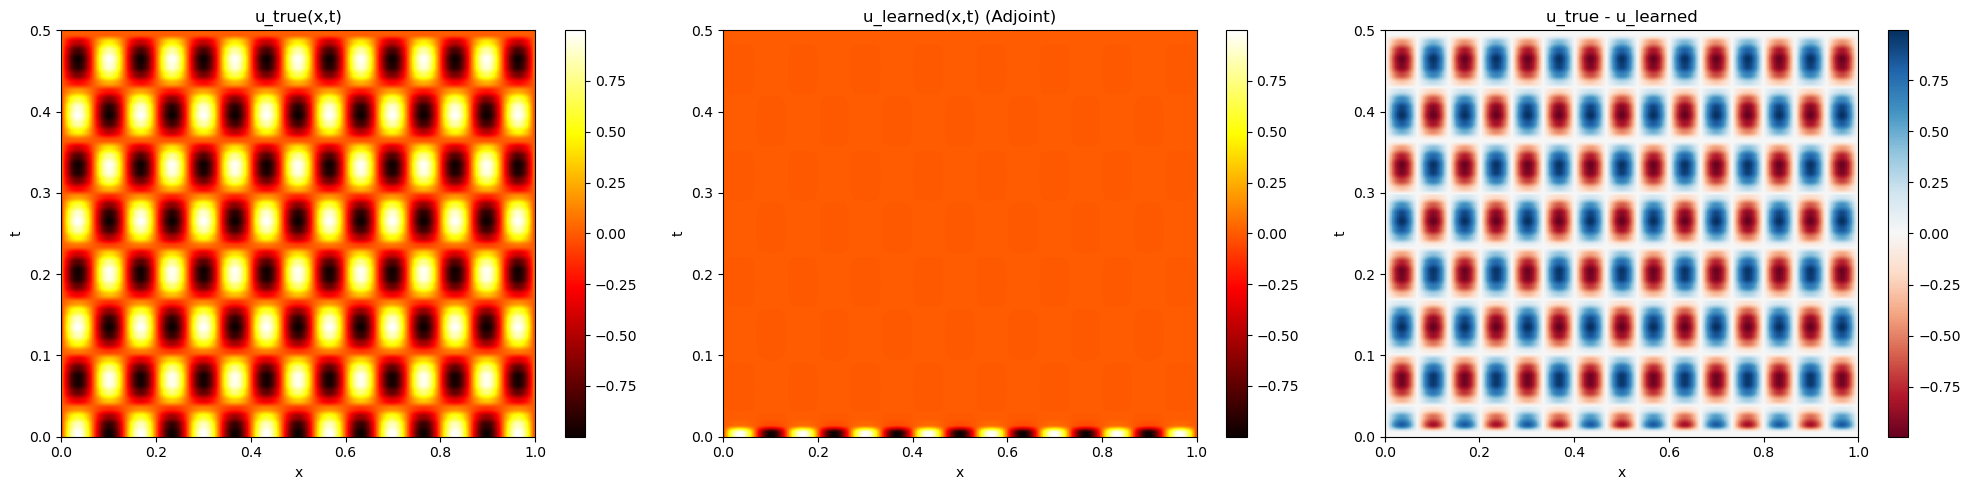

In [7]:
# time axis: nt points, space axis: nx points
time_slices = [1, nt // 2, nt - 2]   # pick whatever you agreed on

fig, axes = plt.subplots(len(time_slices), 1, figsize=(10, 8))

for idx, t_idx in enumerate(time_slices):
    axes[idx].plot(x, f_true[t_idx, :], label='True f', linewidth=2)
    axes[idx].plot(x, f_guess[t_idx, :], '--', label='Adjoint learned f', linewidth=2)
    axes[idx].set_ylabel('f(x,t)')
    axes[idx].set_title(f't = {t[t_idx]:.3f}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

axes[-1].set_xlabel('x')

plt.tight_layout()
plt.show()

# u_true is already the manufactured solution on the grid (nt, nx)
u_traj_true = u_true

# run your forward solver from the *learned* forcing
u_traj_learned = solve_forward(f_guess)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# True u
im0 = axes[0].imshow(
    u_traj_true,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[0].set_title('u_true(x,t)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
fig.colorbar(im0, ax=axes[0])

# Learned u
im1 = axes[1].imshow(
    u_traj_learned,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='hot'
)
axes[1].set_title('u_learned(x,t) (Adjoint)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
fig.colorbar(im1, ax=axes[1])

# Difference
im2 = axes[2].imshow(
    u_traj_true - u_traj_learned,
    aspect='auto',
    origin='lower',
    extent=[x[0], x[-1], t[0], t[-1]],
    cmap='RdBu'
)
axes[2].set_title('u_true - u_learned')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
